In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy.linalg import norm

In [2]:
from dgp import generate_gaussian_data
from methods import solve_independent, aggregate_results, solve_dependent
from metrics import rv_coefficient, mse
from plot_functions import plot_grid, plot_with_bands

In [3]:
rng = np.random.default_rng(1)
n = 2000
k = 2
edge_var = 1
sigma = 0

A, B, Z, X = generate_gaussian_data(n, k, sigma, edge_var=edge_var, rng=rng)

Zhat, evals_A = solve_independent(A, k=k)
Xhat, evals_B = solve_independent(B, k=k)

rv_coefficient(A, B), rv_coefficient(Zhat, Xhat), rv_coefficient(Z, X)

(np.float64(0.0015890096679436825),
 np.float64(0.0010454862603154257),
 np.float64(0.0010183645027060952))

#### Consistencty under independence

In [4]:
import pandas as pd
import itertools    

def simulation(nsim, n, k, sigma, edge_var, dgp, metric, rng, solver):
    if not isinstance(dgp, list):
        dgp = [dgp]
    if not isinstance(sigma, list):
        sigma = [sigma]
    if not isinstance(edge_var, list):
        edge_var = [edge_var]
    if not isinstance(n, list):
        n = [n]
    if not isinstance(k, list):
        k = [k]

    factorial_design = list(itertools.product(n, k, sigma, edge_var, dgp))
    out = []
    
    for i in range(nsim):
        for scenario in factorial_design:
            n, k, sigma, edge_var, dgp = scenario
            A, B, Z, X = dgp(n, k, sigma, edge_var=edge_var, rng=rng)
            Zhat, evals_A = solver(A, k=k)
            Xhat, evals_B = solver(B, k=k)
            err_x = metric(Xhat, X)
            err_z = metric(Zhat, Z)
            out.append({'n': n, 'k': k, 'sigma': sigma, 'edge_var': edge_var, 'err_x': err_x, 'err_z': err_z})
    return pd.DataFrame(out)

In [5]:
nsim = 10
n = [10, 20, 100, 200]
sigma = 0
edge_var = [1, 5, 10]
k = [1, 3, 5]
rng = np.random.default_rng(1)

out = simulation(nsim=nsim, n=n, k=k, sigma=sigma, edge_var=edge_var, 
                 dgp=generate_gaussian_data, metric=mse, rng=rng, solver=solve_independent)

In [6]:
out_x = out.drop(columns=['err_z'])
out_z = out.drop(columns=['err_x'])

agg_out_x = aggregate_results(out_x, y_axis='err_x', x_axis='n', factors=['k', 'edge_var'])
agg_out_z = aggregate_results(out_z, y_axis='err_z', x_axis='n', factors=['k', 'edge_var'])

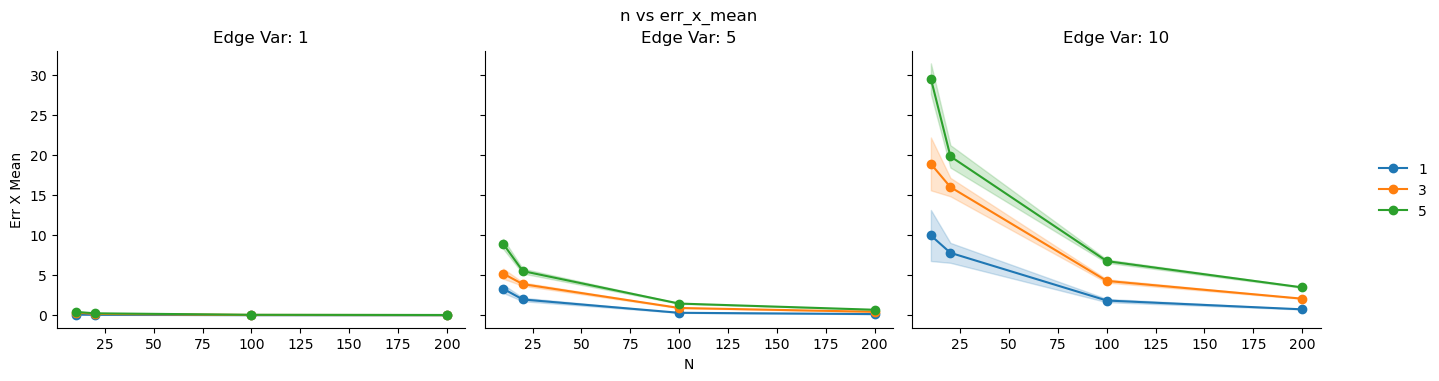

In [7]:
plot_grid(
        grouped_stats=agg_out_x,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='err_x_mean',
        factors=['k', 'edge_var'],
        height=3.5,
        se_bands='err_x_sem'
    )

In [8]:
rng = np.random.default_rng(1)
A, B, Z, X = generate_gaussian_data(n=100, k=2, sigma=0, edge_var=2, rng=rng)
M = np.block([[Z@Z.T, X@Z.T], [X@Z.T, Z@Z.T]])

In [9]:
Ms = solve_dependent(A, B, k=2, niters=10)

In [10]:
def simulation(nsim, n, k, sigma, edge_var, dgp, metric, rng, solver):
    if not isinstance(dgp, list):
        dgp = [dgp]
    if not isinstance(sigma, list):
        sigma = [sigma]
    if not isinstance(edge_var, list):
        edge_var = [edge_var]
    if not isinstance(n, list):
        n = [n]
    if not isinstance(k, list):
        k = [k]

    factorial_design = list(itertools.product(n, k, sigma, edge_var, dgp))
    out = []
    
    for _ in range(nsim):
        for scenario in factorial_design:
            n, k, sigma, edge_var, dgp = scenario
            A, B, Z, X = dgp(n, k, sigma, edge_var=edge_var, rng=rng)
            true_M = np.block([[Z@Z.T, X@Z.T], [X@Z.T, Z@Z.T]])
            estimated_M, estimated_sigma = solver(A, B, k=k, niters=10)

            err_M = metric(estimated_M, true_M)
            err_sigma = np.abs(estimated_sigma - sigma)
            out.append({'n': n, 'k': k, 'sigma': sigma, 'edge_var': edge_var, 'err_M': err_M, 'err_sigma': err_sigma})
    return pd.DataFrame(out)

In [11]:
from functools import partial

nsim = 5
n = [10, 20, 100, 200, 500]
sigma = 0.99
edge_var = 1
k = 2
step_size = 0.1
rng = np.random.default_rng(1)

solver = partial(solve_dependent, step_size=step_size)

out = simulation(nsim=nsim, n=n, k=k, sigma=sigma, edge_var=edge_var, 
                 dgp=generate_gaussian_data, metric=mse, rng=rng, 
                 solver=solver)

In [12]:
out.groupby('n').mean()[['err_M', 'err_sigma']]

,err_M,err_sigma
n,,
10,1.157510e+05,1.499501
20,1.726787e+05,1.358045
100,6.808798e+05,0.851156
200,1.897928e+06,1.751549
500,1.062055e+07,1.180611


#### Independence test

In [13]:
rng = np.random.default_rng(1)
n = 50
k = 5
edge_var = 5
sigma = 0

A, B, Z, X = generate_gaussian_data(n, k, sigma, edge_var=edge_var, rng=rng)

Zhat, evals_A = solve_independent(A, k=k)
Xhat, evals_B = solve_independent(B, k=k)
rv_est = rv_coefficient(Zhat, Xhat)
rv_coefficient(A, B), rv_coefficient(Zhat, Xhat), rv_coefficient(Z, X)

(np.float64(0.34375408461655205),
 np.float64(0.1289463391370709),
 np.float64(0.1320006840058403))

In [14]:
n_perm = 100
rv_distr = []
for i in range(n_perm):
    perm = rng.permutation(n)
    X_perm = X[perm, :]
    rv_perm = rv_coefficient(X_perm, Z)
    rv_distr.append(rv_perm)

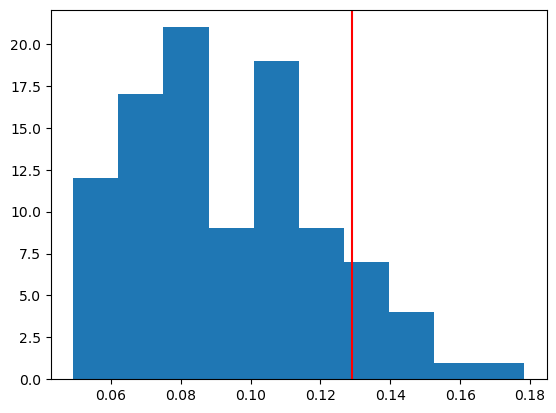

In [15]:
fig, ax = plt.subplots()
ax.hist(rv_distr)
ax.axvline(rv_est, color='red')
plt.show()